# Importing Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Loading the dataset

In [58]:
# creating database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summart",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,purchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
- Previously, we have examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with furthur analysis.

In [59]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchasePrice,10692.0,24.385303,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


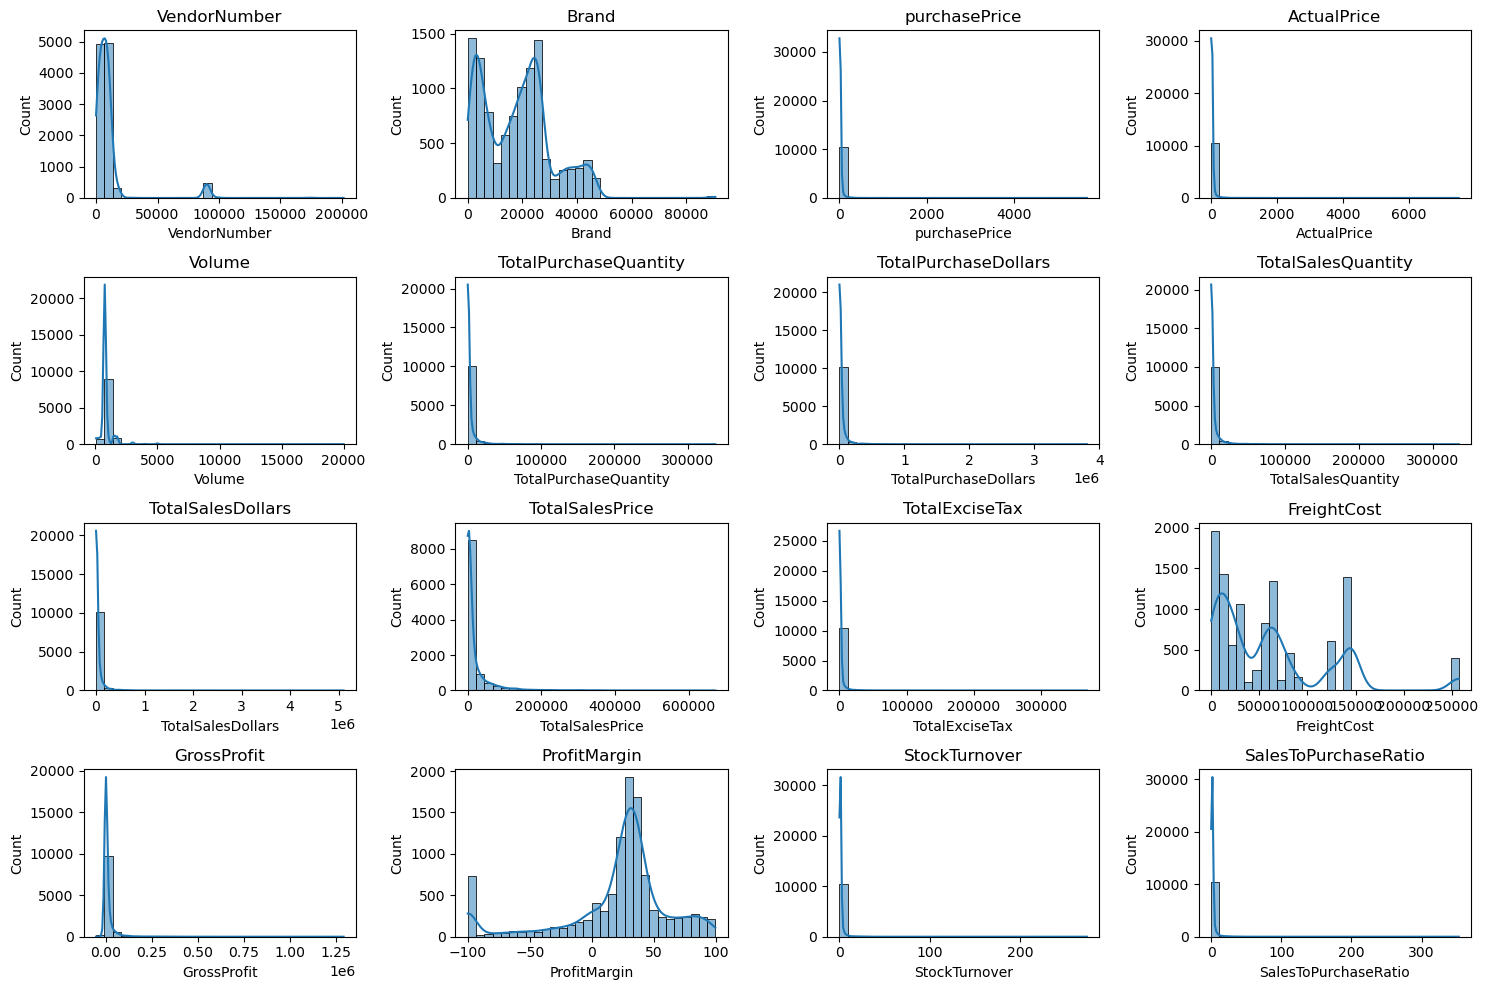

In [60]:
# Distribution Plots for Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

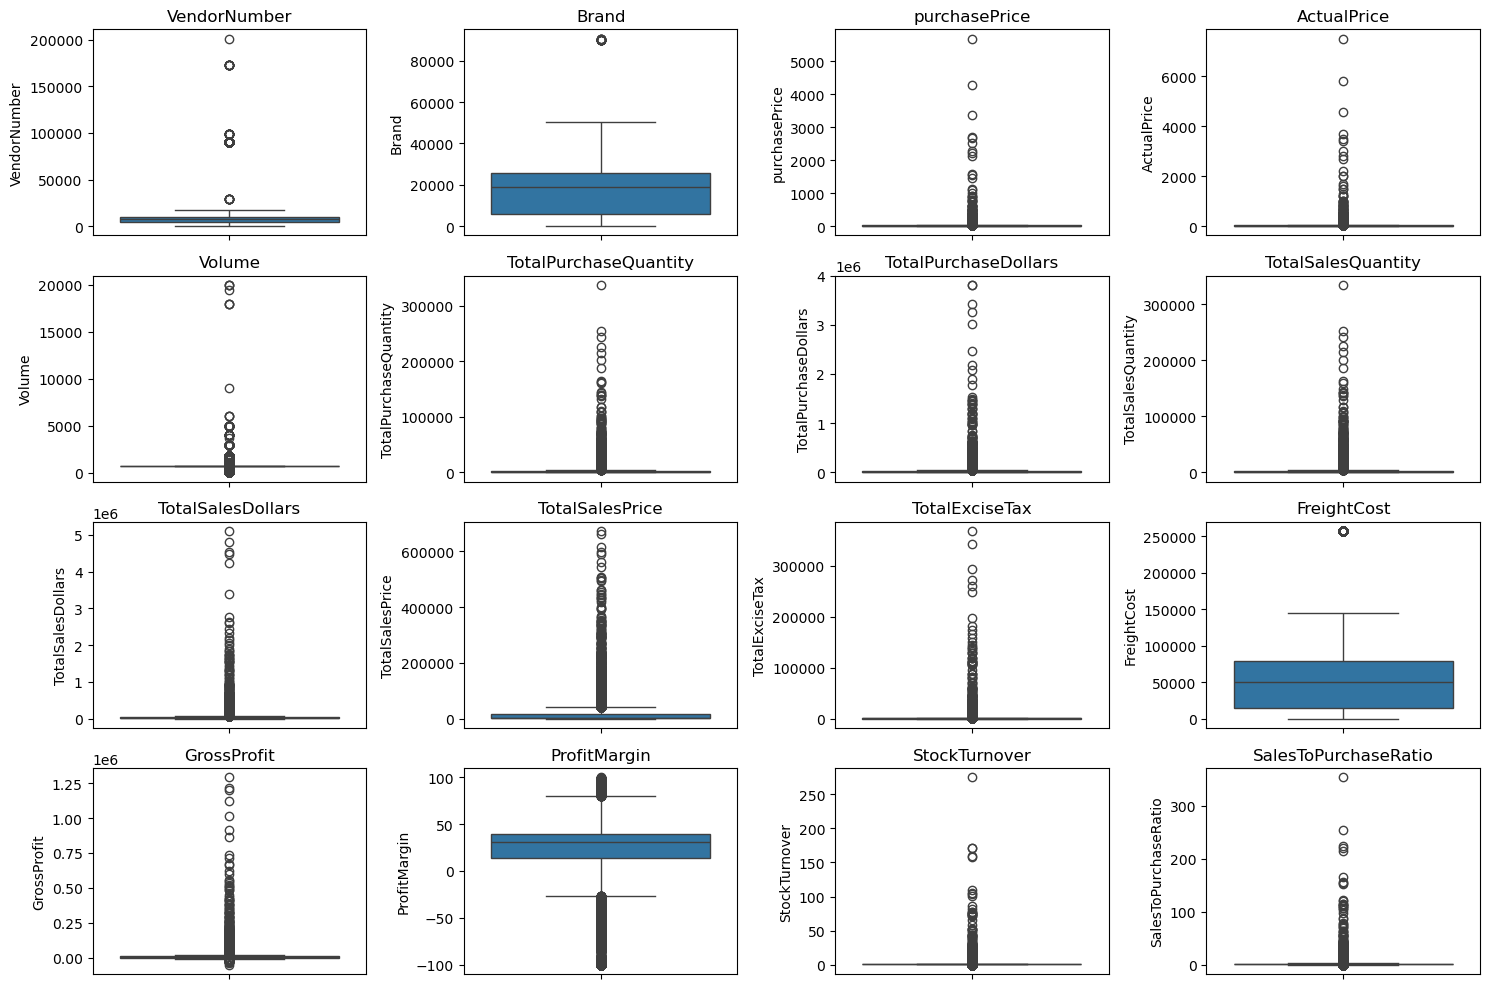

In [61]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:
**Negative & Zero Values:**
- Gross Profit: Minimum value is -52,002.78, including losses. Some products or transactions may be selling at a loss due to hogh costs or selling at discounts lower than the purchase price.
- Profit Margin: Has a minimum of -infinity, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Dollar: Minimum values are 0, meaning some products were purchased but never sold. These could be slow- moving or obsolute stock.

**Outliers indicated by high Standard Deviation:**
- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation, from 0.09 to 2,57,032.07, suggests logistics insufficient or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinetly. Values more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stocks.

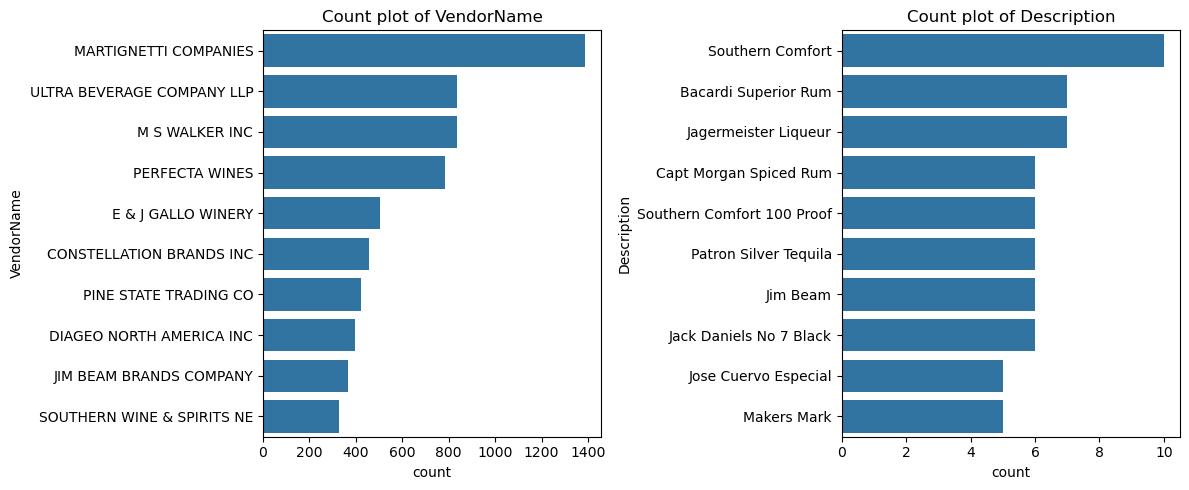

In [62]:
# Count plots for categorical columns
categorical_cols = ["VendorName" , "Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

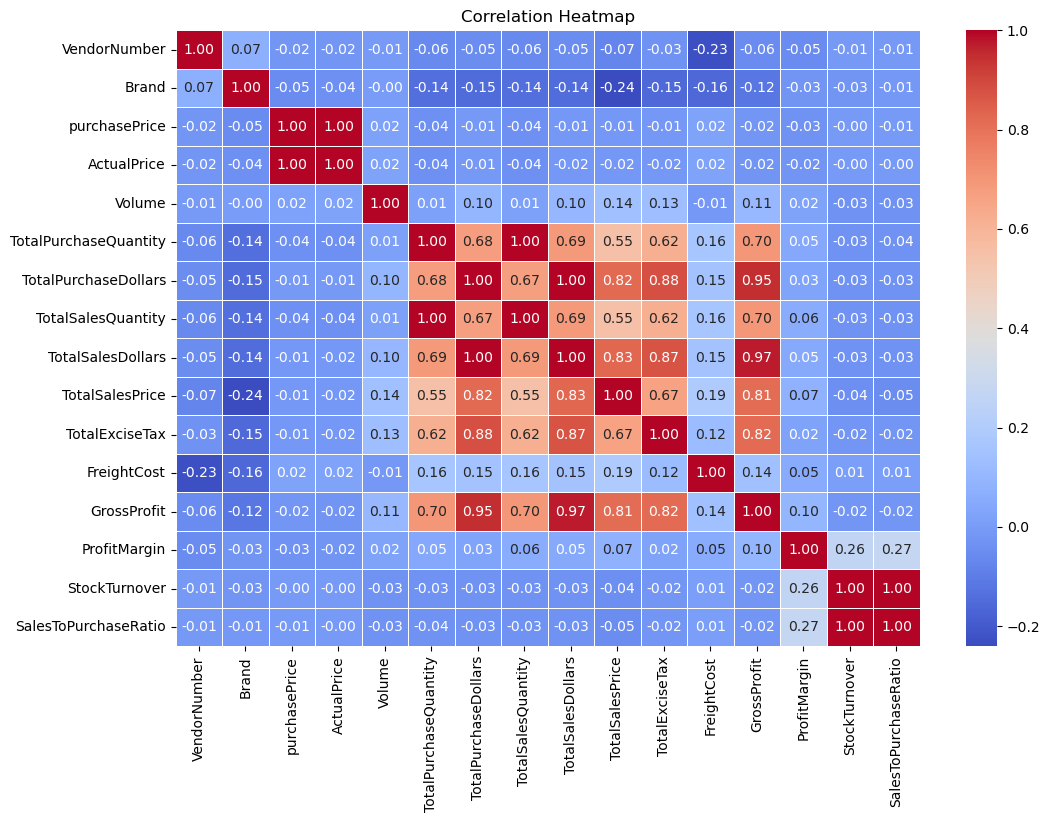

In [63]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df [numerical_cols].corr()
sns.heatmap(correlation_matrix, annot= True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation insights
- PurchasePrice has weak correlations with TotalSalesDollar(-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margin decreases, possibly due to competitive pricing pressures.
- Stock Turnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.0555), including that faster turnover does not necessarily result in higher profitability.

# DATA ANALYSIS

#### Identify Brands that needs Promotional or Pricing adjustments which exibits lower sales performance but higher profit margins

In [85]:
brand_performance= df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean' }).reset_index()

brand_performance = brand_performance[
    brand_performance['TotalSalesDollars'] > 0
].copy()


In [86]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [87]:
low_sales_threshold

np.float64(341.84)

In [88]:
high_margin_threshold

np.float64(56.61836630078476)

In [89]:
#Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low sales but high profit margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
7777,Santa Rita Organic Svgn Bl,9.99,66.466466
2896,Debauchery Pnt Nr,11.58,65.975820
2537,Concannon Glen Ellen Wh Zin,15.95,83.448276
2677,Crown Royal Apple,27.86,89.806174
7818,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
251,Alta Classe Mntplcno Abruzzo,327.59,60.731402
2066,Ch Musar Hochar Red,329.89,81.448362
1968,Ch La Dom St Emil Gr Cru 09,334.95,73.333333
6120,Mimosa by St Clair Winery,335.76,67.333810


In [90]:
brand_performance= brand_performance[brand_performance['TotalSalesDollars']<10000]

<function matplotlib.pyplot.show(close=None, block=None)>

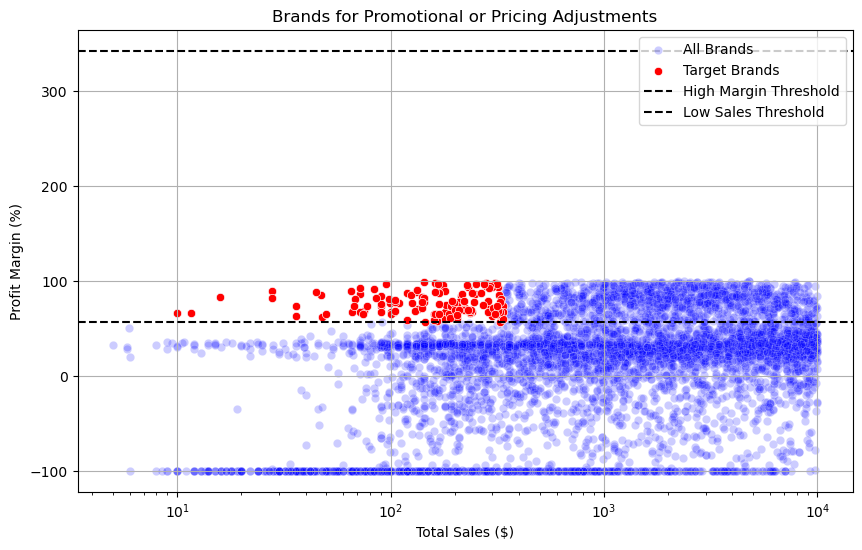

In [91]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axhline(low_sales_threshold, linestyle='--', color="black", label="Low Sales Threshold")

plt.xscale('log')

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show

In [70]:
brand_performance.sort_values('ProfitMargin').head(10)

,Description,TotalSalesDollars,ProfitMargin
8452,Suerte Reposado Tequila,4428.91,-100.0
36,19 Crimes The Banished Red,38.97,-100.0
38,2 Copas Spain Red,9.99,-100.0
5592,Long Barn Pnt Nr,13.99,-100.0
5594,Long Lake Chard Cal,35.94,-100.0
3151,Down Under Cellars Shiraz,11.99,-100.0
3148,Douglass Hill Pnt Grigio,23.96,-100.0
3129,Don Simon Selecion Shiraz,29.94,-100.0
5643,Lucien Boillot & Fils Volnay,65.99,-100.0
1496,Canary Hill Vyd Pnt Nr,144.95,-100.0


#### Which vendors and brands demonstrate the highest sales performance

In [94]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/ 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/ 1_000:.2f}K"
    else:
        return str(value)

In [95]:
# Top 10 vendors & brands by sales performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands= df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      68739834.97
MARTIGNETTI COMPANIES         40960117.82
PERNOD RICARD USA             32279544.17
JIM BEAM BRANDS COMPANY       31898621.16
BACARDI USA INC               25005365.79
CONSTELLATION BRANDS INC      24467134.23
E & J GALLO WINERY            18553774.66
BROWN-FORMAN CORP             18476611.60
ULTRA BEVERAGE COMPANY LLP    17802646.10
M S WALKER INC                15436066.26
Name: TotalSalesDollars, dtype: float64

In [96]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [97]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

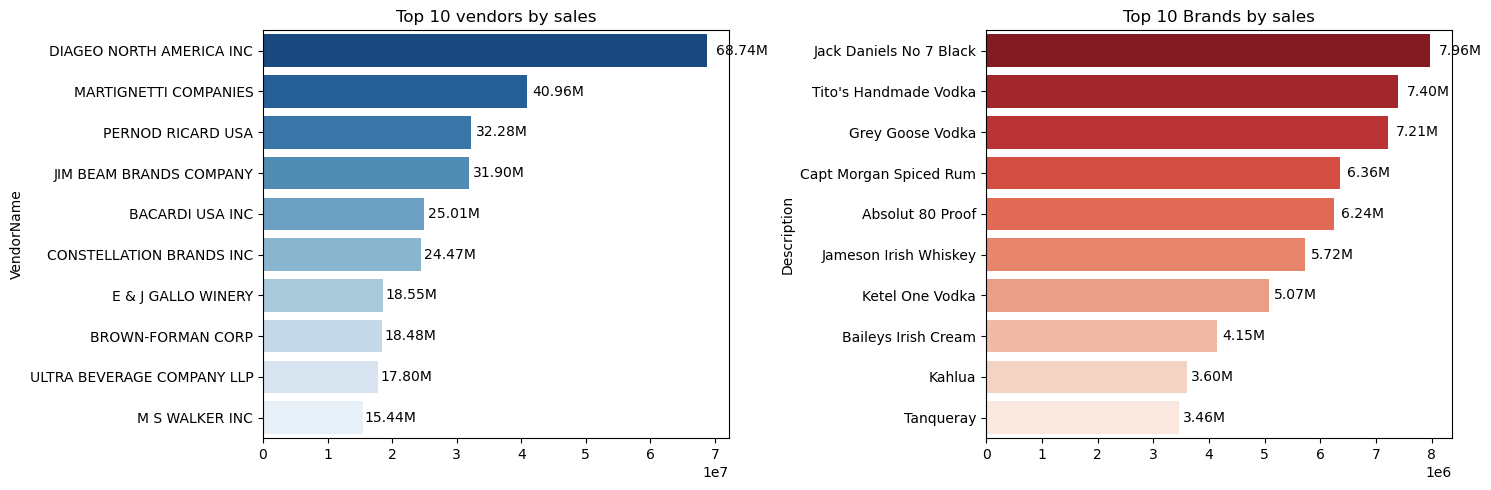

In [99]:
plt.figure(figsize=(15,5))

#Plot for Top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width()*0.02),
            bar.get_y() + bar.get_height()/2,
            format_dollars(bar.get_width()),
            ha='left' , va='center',fontsize=10,color='black')
#Plot for Top Brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() *0.02),
            bar.get_y() + bar.get_height()/2,
            format_dollars(bar.get_width()),
            ha='left', va='center',fontsize=10,color='black')

plt.tight_layout()
plt.show()

#### Which vendors contribute the most to total purchase dollars?

In [101]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()

In [118]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [119]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [120]:
#Display Top 10 vendors
top_vendors= vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,50.96M,17.78M,68.74M,15.83
63,MARTIGNETTI COMPANIES,27.86M,13.10M,40.96M,8.66
50,JIM BEAM BRANDS COMPANY,24.20M,7.70M,31.90M,7.52
74,PERNOD RICARD USA,24.12M,8.16M,32.28M,7.49
8,BACARDI USA INC,17.62M,7.38M,25.01M,5.48
23,CONSTELLATION BRANDS INC,15.57M,8.89M,24.47M,4.84
14,BROWN-FORMAN CORP,13.53M,4.95M,18.48M,4.20
114,ULTRA BEVERAGE COMPANY LLP,13.21M,4.59M,17.80M,4.10
33,E & J GALLO WINERY,12.29M,6.26M,18.55M,3.82
59,M S WALKER INC,10.94M,4.50M,15.44M,3.40


In [121]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.34)

In [126]:
print(top_vendors.columns)

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%', 'Cumulative_Contribution',
       'Cumulative_Contribution%'],
      dtype='object')


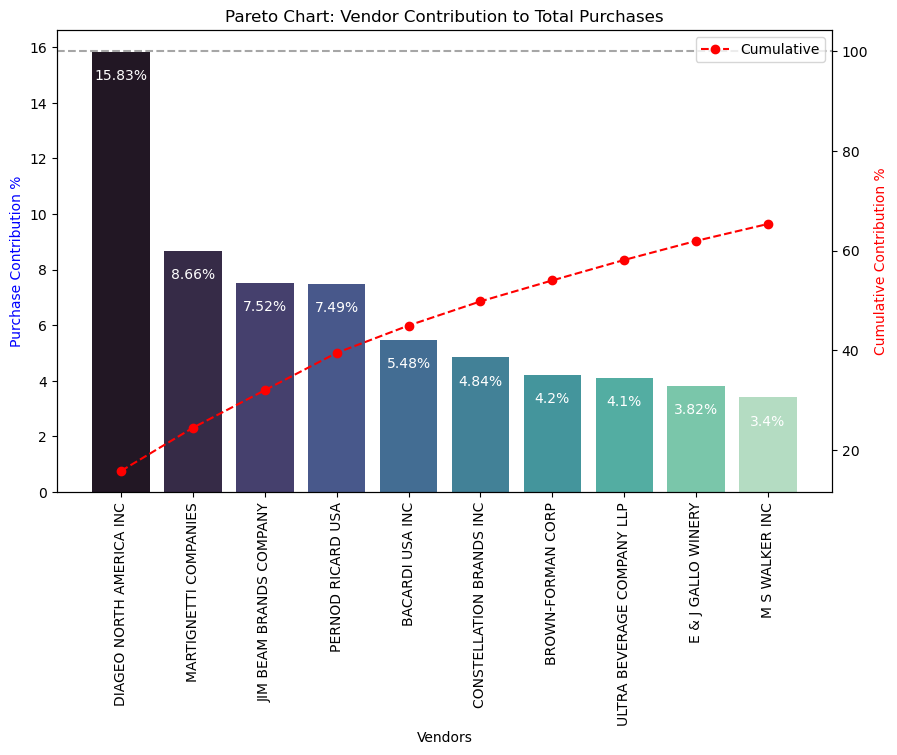

In [131]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value-1, str(value)+'%', ha='center', fontsize=10, color= 'white')

#Line Plot for cumulative contribution
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

#### How much of total procurement is dependent on top vendors

In [132]:
 print(f"Toral Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Toral Purchase Contribution of top 10 vendors is 65.34%


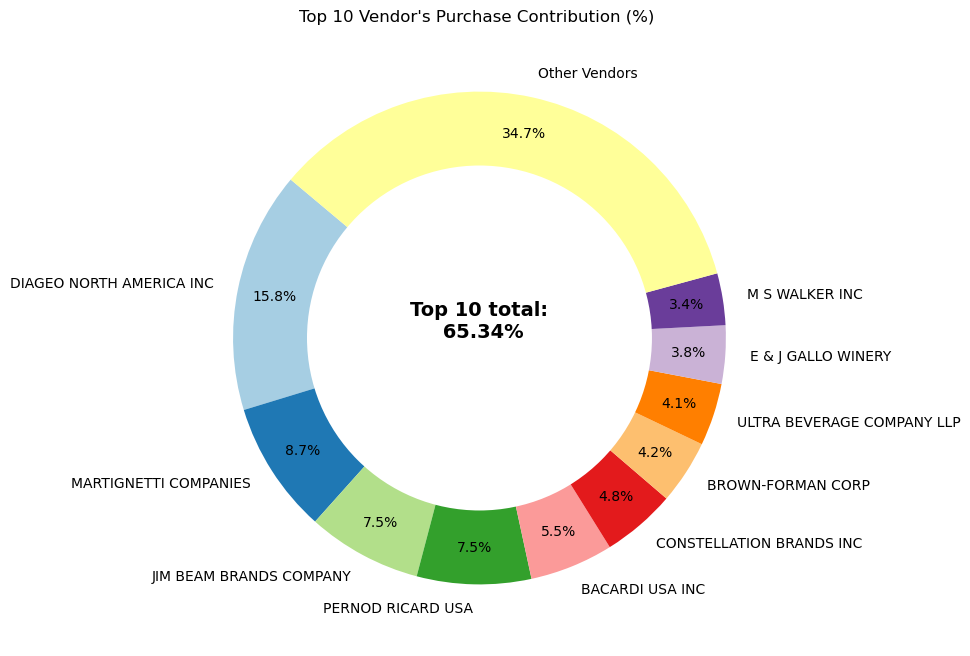

In [136]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart 
fig, ax1 =plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax1.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors= plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
center_circle = plt.Circle((0,0),0.70, fc='white')
fig.gca().add_artist(center_circle)

#Add Total Contribution annotation in the center
plt.text(0,0, f"Top 10 total:\n{total_contribution: .2f}%",fontsize= 14, fontweight='bold', ha='center')

plt.title("Top 10 Vendor's Purchase Contribution (%) ")
plt.show()

#### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving

In [139]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [140]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [141]:
df['OrderSize']

0        Large
1        Large
2        Large
3        Large
4        Large
         ...  
10687    Small
10688    Small
10689    Small
10690    Small
10691    Small
Name: OrderSize, Length: 10692, dtype: category
Categories (3, object): ['Small' < 'Medium' < 'Large']

In [143]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


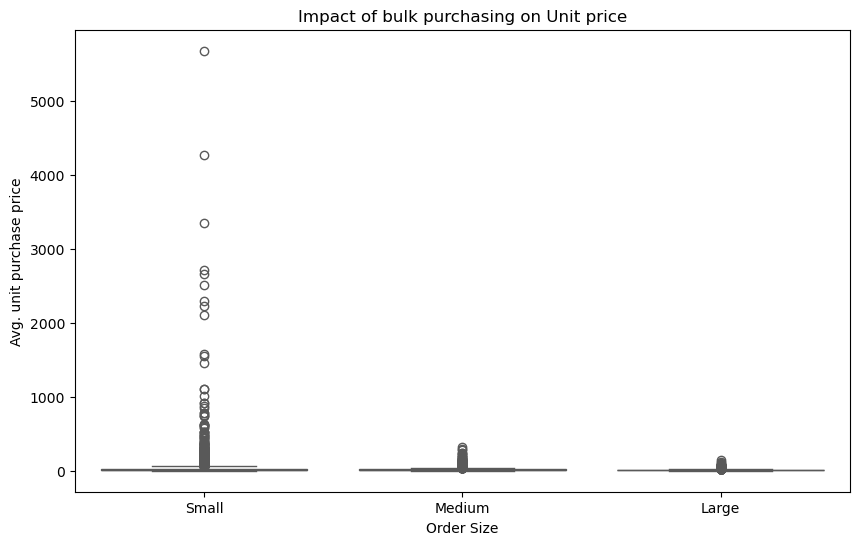

In [144]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of bulk purchasing on Unit price")
plt.xlabel("Order Size")
plt.ylabel("Avg. unit purchase price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between small and large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing statergies successfully encourage vendors to purchase in large volumes, leading to higher overall sales despite lower per-revenue

**Which vendors have low inventory turnover, indicating excess stock and slow - moving products?**

In [148]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending= True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
UNCORKED,0.217238
MILTONS DISTRIBUTING CO,0.236111
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [156]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["purchasePrice"]
print('Total Unsold Captial:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Captial: 8.75M


In [157]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] =inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,980.09K
63,MARTIGNETTI COMPANIES,928.99K
50,JIM BEAM BRANDS COMPANY,857.80K
114,ULTRA BEVERAGE COMPANY LLP,780.27K
73,PERFECTA WINES,571.81K
74,PERNOD RICARD USA,554.74K
59,M S WALKER INC,469.96K
125,WILLIAM GRANT & SONS INC,436.49K
33,E & J GALLO WINERY,315.20K
14,BROWN-FORMAN CORP,284.91K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [158]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [161]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [162]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
5530    93.085860
5648    90.021514
5651    89.883453
5773    95.012530
5945    94.271857
Name: ProfitMargin, Length: 2673, dtype: float64

In [163]:
low_vendors

2147    -100.000000
2456       0.000000
2462    -100.000000
2528       0.000000
2982       0.000000
            ...    
10687     83.448276
10688     96.436186
10689     25.252525
10690     98.974037
10691     99.166079
Name: ProfitMargin, Length: 2673, dtype: float64

In [168]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1)/ np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence)/2, df=len(data)-1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (29.53,30.55), Mean: 30.04
Low Vendors 95% CI(-4.80, -0.36, Mean: -2.58


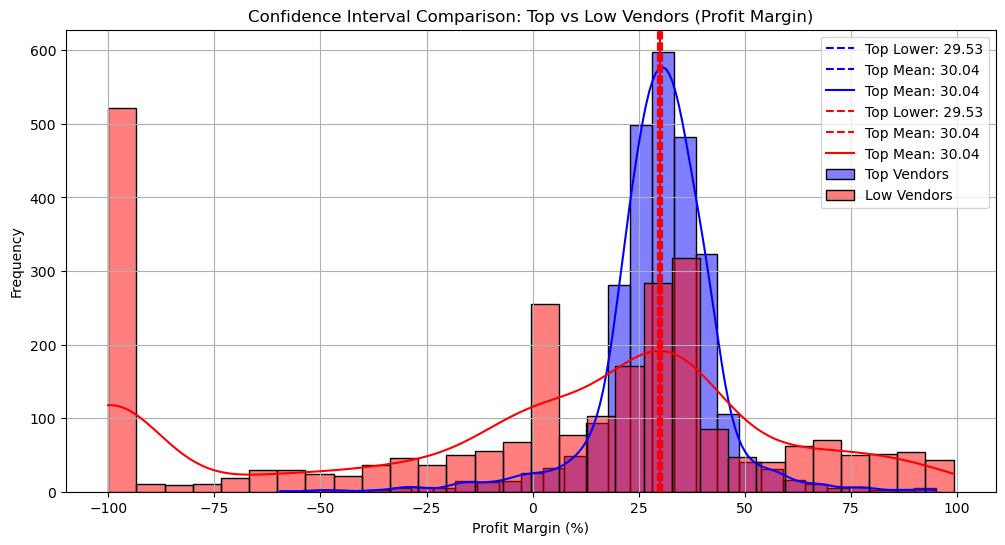

In [172]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower,low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f},{top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI({low_lower:.2f}, {low_upper:.2f}, Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

# Top vendors plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper , color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}" )
plt.axvline(top_mean, color="blue", linestyle='-', label=f"Top Mean: {top_mean:.2f}")

# Low vendor plots
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(top_lower, color="red", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper , color="red", linestyle="--", label=f"Top Mean: {top_mean:.2f}" )
plt.axvline(top_mean, color="red", linestyle='-', label=f"Top Mean: {top_mean:.2f}")

# Finalize Plot 
plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors(40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling stratergies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution stratergies. 

#### Is there a significant difference in profit margin between top-performing and low-performing vendors?
Hypothesis:
<br>
$H_0$ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low performing vendors.
<br>
$H_1$ (Alternative Hypothesis): The mean profit margins of top- performing and low performing vendors are significantly different.

In [173]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <=low_threshold]["ProfitMargin"].dropna()

#Perform Two-sample T-test
t_stats, p_value = ttest_ind(top_vendors, low_vendors,equal_var=False)

#Print results
print(f"T-Statistic: {t_stats:.4f}, P-value:{p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low- performing vendors")
else:
    print("Fail to Reject H₀: No significant difference in  profit margins.")

T-Statistic: 28.0916, P-value:0.0000
Reject H₀: There is a significant difference in profit margins between top and low- performing vendors
